<a href="https://colab.research.google.com/gist/UrviWalia/b56c1d0107b9b9ea1948822d5947d0ae/tsla-analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df=yf.download("TSLA",start='2023-04-01',end='2025-04-01')

[*********************100%***********************]  1 of 1 completed


In [ ]:
df

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2023-04-03,194.770004,202.690002,192.199997,199.910004,169545900
2023-04-04,192.580002,198.740005,190.320007,197.320007,126463800
2023-04-05,185.520004,190.679993,183.759995,190.520004,133882500
2023-04-06,185.059998,186.389999,179.740005,183.080002,123857900
2023-04-10,184.509995,185.100006,176.110001,179.940002,142154600
...,...,...,...,...,...
2025-03-25,288.140015,288.200012,271.279999,283.600006,150361500
2025-03-26,272.059998,284.899994,266.510010,282.660004,153629800


In [ ]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2023-04-03,194.770004,202.690002,192.199997,199.910004,169545900
2023-04-04,192.580002,198.740005,190.320007,197.320007,126463800
2023-04-05,185.520004,190.679993,183.759995,190.520004,133882500
2023-04-06,185.059998,186.389999,179.740005,183.080002,123857900
2023-04-10,184.509995,185.100006,176.110001,179.940002,142154600


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 500 entries, 2023-04-03 to 2025-03-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, TSLA)   500 non-null    float64
 1   (High, TSLA)    500 non-null    float64
 2   (Low, TSLA)     500 non-null    float64
 3   (Open, TSLA)    500 non-null    float64
 4   (Volume, TSLA)  500 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 23.4 KB


In [ ]:
df.columns

MultiIndex([( 'Close', 'TSLA'),
            (  'High', 'TSLA'),
            (   'Low', 'TSLA'),
            (  'Open', 'TSLA'),
            ('Volume', 'TSLA')],
           names=['Price', 'Ticker'])

In [ ]:
df['Daily_Return']=df['Close'].pct_change()
df['Volatility']=df['High']-df['Low']
df['Year']=df.index.year
df['Month']=df.index.month
df['Day']=df.index.day
df['Weekday']=df.index.weekday

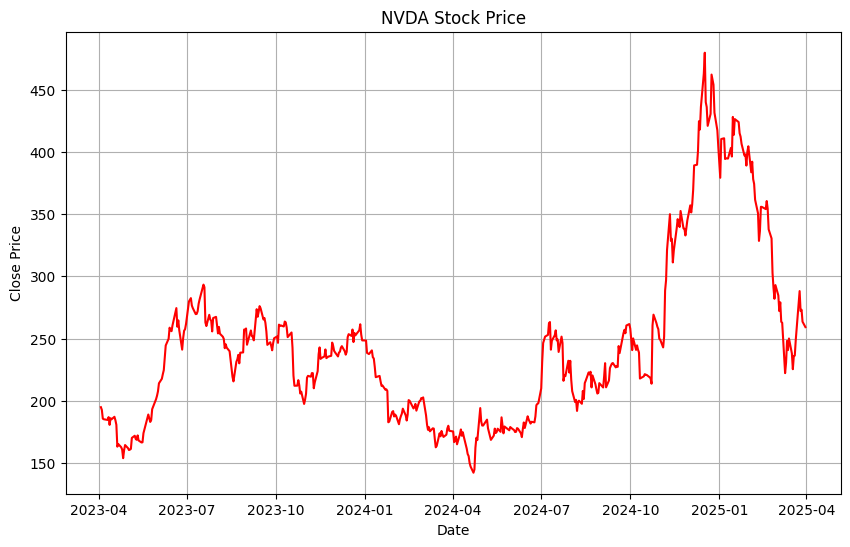

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(df.index, df['Close'],color='red')
plt.title("NVDA Stock Price")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.grid(True)
plt.show()

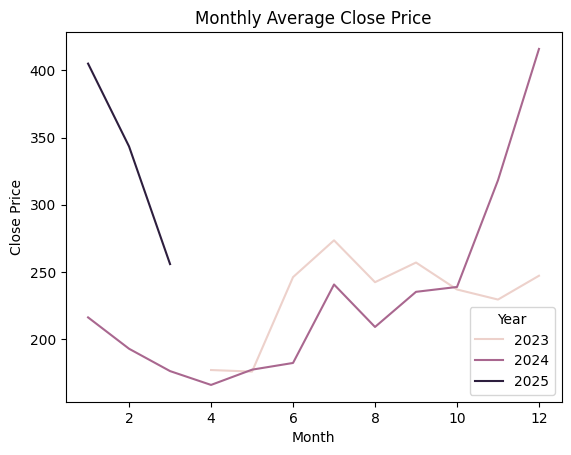

In [ ]:
monthly=df.groupby(['Year','Month'])['Close'].mean().reset_index()
sns.lineplot(data=monthly,x='Month',y=('Close', 'TSLA'),hue='Year')
plt.title("Monthly Average Close Price")
plt.xlabel("Month")
plt.ylabel("Close Price")
plt.show()

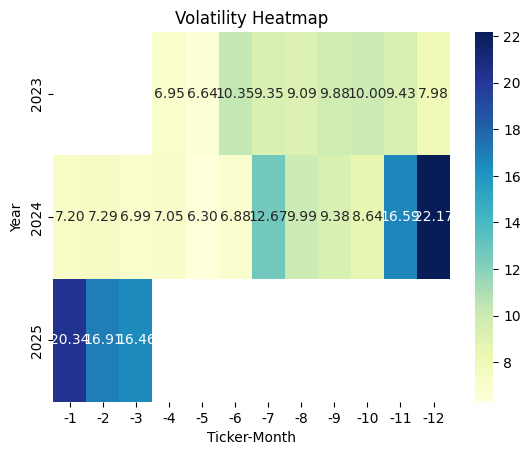

In [ ]:
pivot_table=df.pivot_table(values='Volatility',index='Year',columns='Month')
sns.heatmap(pivot_table, cmap='YlGnBu', annot=True, fmt='.2f')
plt.title("Volatility Heatmap")
plt.show()

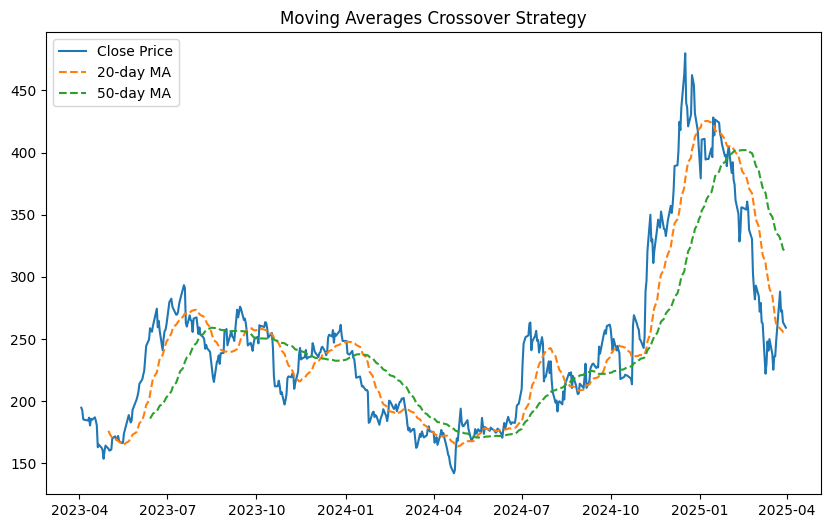

In [ ]:
df['MA20'] = df['Close'].rolling(window=20).mean()
df['MA50'] = df['Close'].rolling(window=50).mean()

plt.figure(figsize=(10,6))
plt.plot(df['Close'], label='Close Price')
plt.plot(df['MA20'], label='20-day MA', linestyle='--')
plt.plot(df['MA50'], label='50-day MA', linestyle='--')
plt.title("Moving Averages Crossover Strategy")
plt.legend()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
df['Price_Movement'] = np.where(df[('Close', 'TSLA')].shift(-1) > df[('Close', 'TSLA')], 1, 0)
df = df.dropna()
X = df[['Open', 'High', 'Low', 'Volume', 'MA20', 'MA50']]
y = df['Price_Movement']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

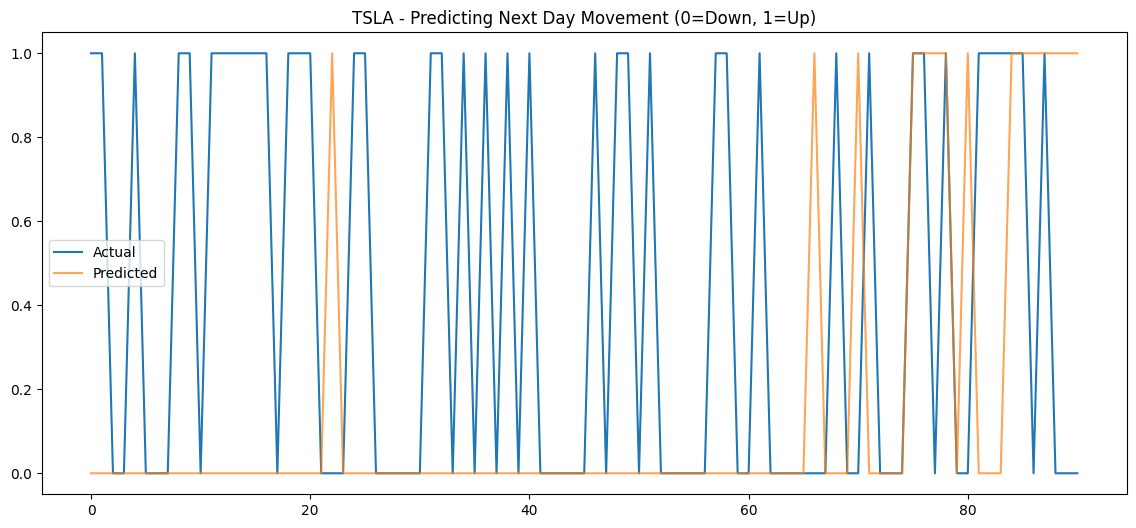

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted', alpha=0.7)
plt.title(f"TSLA - Predicting Next Day Movement (0=Down, 1=Up)")
plt.legend()
plt.show()